# criar um modelo de regressão linear para prever qual será o investimento inicial necessário de uma franquia a partir de uma taxa anual cobrada pelo franqueador


In [3]:
#importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
#Narning
!pip install yellowbrick
from yellowbrick.regressor import ResidualsPlot


In [9]:
# carregar base de dados

df = pd.read_csv("slr12.csv", sep=";")
df.shape

(36, 2)

In [10]:
df.head()

,FrqAnual,CusInic
0,1000,1050
1,1125,1150
2,1087,1213
3,1070,1275
4,1100,1300


In [13]:
#FrqAnual = taxa anual y
#Cuslnic = investimento inicial x
# Definir valores para as variaveis x e y
# x = indepentende investimento inicial
# y = dependente taxa anual

x = df.iloc[:,1].values
y = df.iloc[:,0].values
x

array([1050, 1150, 1213, 1275, 1300, 1300, 1400, 1400, 1250, 1830, 1350,
       1450, 1300, 1300, 1275, 1375, 1285, 1400, 1400, 1285, 1275, 1135,
       1250, 1275, 1150, 1250, 1275, 1225, 1280, 1300, 1250, 1175, 1300,
       1250, 1300, 1200], dtype=int64)

In [14]:
y

array([1000, 1125, 1087, 1070, 1100, 1150, 1250, 1150, 1100, 1350, 1275,
       1375, 1175, 1200, 1175, 1300, 1260, 1330, 1325, 1200, 1225, 1090,
       1075, 1080, 1080, 1180, 1225, 1175, 1250, 1250,  750, 1125,  700,
        900,  900,  850], dtype=int64)

In [15]:
# Calcular a Correlação entre x e y

correlação = np.corrcoef(x,y)
correlação

array([[1.        , 0.47700725],
       [0.47700725, 1.        ]])

In [16]:
# formatar matriz com uma coluna
x = x.reshape(-1,1)

In [18]:
# criação de um modelo de treinamente fit indica o treinamento deve ser executado
modelo = LinearRegression()
modelo.fit(x,y)

LinearRegression()

In [19]:
# Visualização dos coeficientes
modelo.intercept_

347.5467344612957

In [20]:
#Inclinação da reta
modelo.coef_

array([0.60975768])

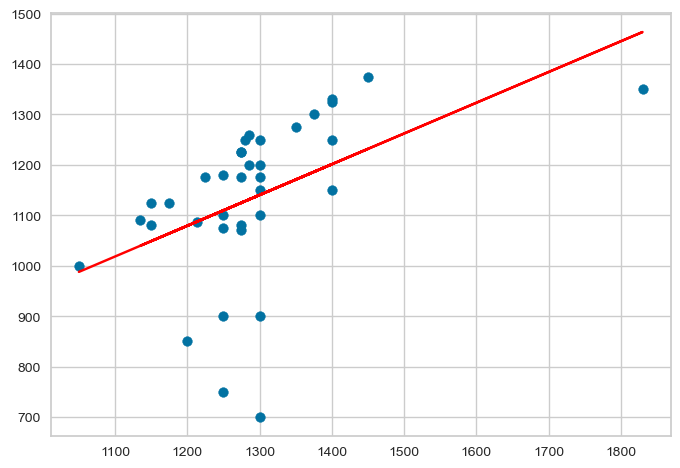

In [21]:
# geração do gradico com os pontos reais e a previsão
plt.scatter (x,y)
plt.plot (x, modelo.predict(x), color = 'red')

In [22]:
# Previsão quando o taxa anual for 1300
modelo.predict([[1300]])

array([1140.23172149])

In [24]:
#Previsão quando taxa anual for 1800
modelo.predict([[1800]])

array([1445.11056266])

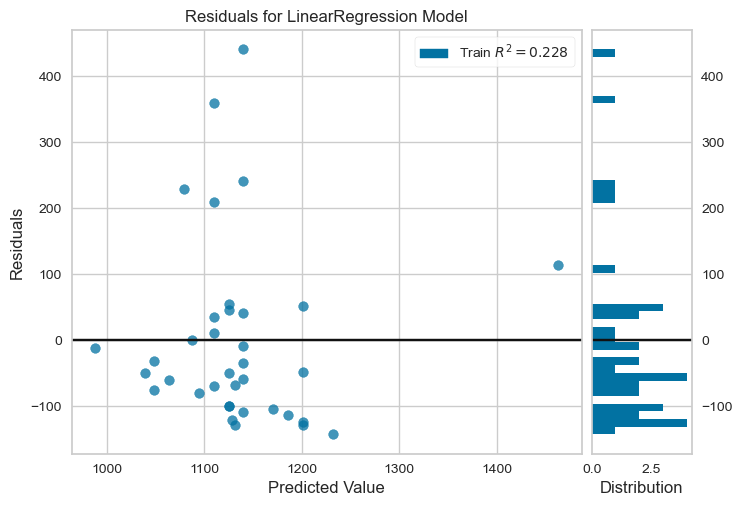

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [23]:
#grafico para vizualizar residuos
visualizador = ResidualsPlot(modelo)
visualizador.fit(x,y)
visualizador.show()